In [1]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [2]:
#
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path
from pprint import pprint
from tqdm.notebook import tqdm

In [3]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import load_config, DEFAULT_CONFIG_FILE

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

# load dataset BirdCLEF
raw_df = pd.read_csv(config.get_dataset_raw_filename())

In [4]:
print("Information sur le data:", config.dataset.data_description_url)

Information sur le data: https://www.kaggle.com/competitions/birdclef-2023/data


In [5]:
print("Dataset shape:", raw_df.shape)

print()

print("Types")
display(raw_df.dtypes.to_frame().T)

Dataset shape: (16941, 12)

Types


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,object,object,object,float64,float64,object,object,object,object,float64,object,object


In [6]:
#
# secondary_labels et type sont des listes
# valider que le parsing est bien ce qu'on pense
#
print("Type element 'secondary_labels':", type(raw_df.loc[0, "secondary_labels"]))
print("Type element 'type':", type(raw_df.loc[0, "type"]))

Type element 'secondary_labels': <class 'str'>
Type element 'type': <class 'str'>


<div class="answer">

On peut voir que la lecture du .csv n'est pas correcte. On devrait avoir une liste.

In [7]:
#
# corriger secondary_labels et type sont des listes
#
if isinstance(raw_df.loc[0, "secondary_labels"], str):
    from ast import literal_eval

    raw_df["secondary_labels"] = raw_df["secondary_labels"].apply(literal_eval)
    raw_df["type"] = raw_df["type"].apply(literal_eval)

print()

print("Affichage succint")
display(raw_df.head())


Affichage succint


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,abethr1,[],[song],4.3906,38.2788,Turdus tephronotus,African Bare-eyed Thrush,Rolf A. de By,Creative Commons Attribution-NonCommercial-Sha...,4.0,https://www.xeno-canto.org/128013,abethr1/XC128013.ogg
1,abethr1,[],[call],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,3.5,https://www.xeno-canto.org/363501,abethr1/XC363501.ogg
2,abethr1,[],[song],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,3.5,https://www.xeno-canto.org/363502,abethr1/XC363502.ogg
3,abethr1,[],[song],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,5.0,https://www.xeno-canto.org/363503,abethr1/XC363503.ogg
4,abethr1,[],"[call, song]",-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,4.5,https://www.xeno-canto.org/363504,abethr1/XC363504.ogg


Stat. generale pour 'type'


,count,mean,std,min,25%,50%,75%,max
0,399.0,63.255639,506.758959,1.0,1.0,1.0,2.0,6808.0


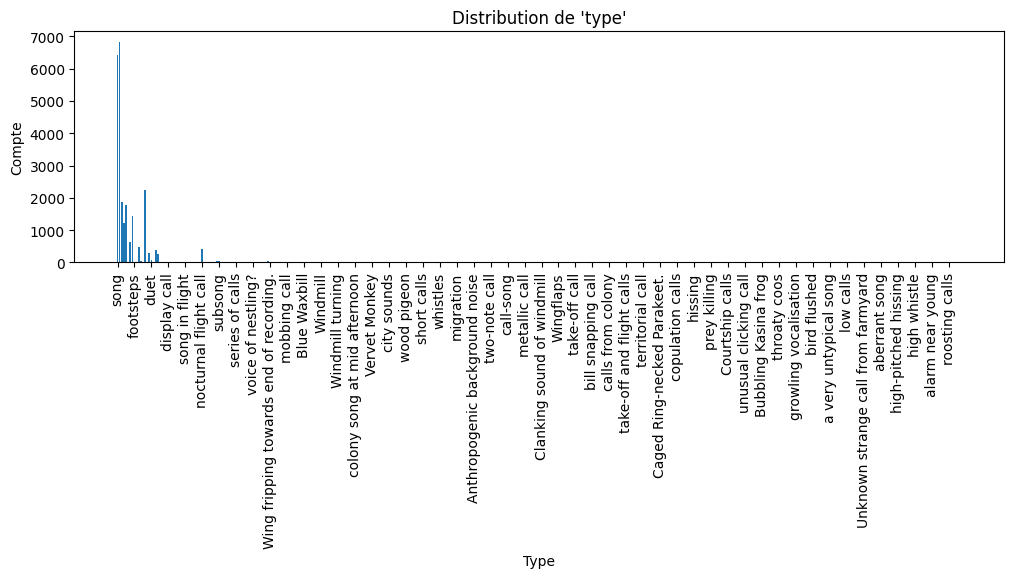

In [8]:
#
# examinder type
#
from itertools import islice

# calculer histogram
def type_histogram(types_, hist_dict):
    for t in types_:
        if t in hist_dict:
            hist_dict[t] += 1
        else:
            hist_dict[t] = 1

hist_dict = {}
raw_df["type"].apply(type_histogram, args=(hist_dict,))

# convertir en Series pandas (simplifie extraction statistiques)
hist_df =  pd.Series(data=hist_dict.values(), index=hist_dict.keys())

# afficher quelques stats
print("Stat. generale pour 'type'")
display(hist_df.describe().to_frame().T)

# afficher histogramme - ne garder que quelques lables car 
# il n'y en a trop pour etre visialise
count = len(hist_dict)
step = 8

plt.figure(figsize=(12, 3))
plt.bar([i for i in range(count)], hist_dict.values())

plt.gca().set_xticks([i for i in range(0, count, step)])
plt.gca().set_xticklabels([k for k in islice(hist_dict.keys(), 0, count, step)], rotation=90)

plt.xlabel("Type")
plt.ylabel("Compte")
plt.title("Distribution de 'type'")
plt.show()

<div class="answer">

* 16941 echantillons
* 12 variables. Selon les informations trouvees via l'url et un examin visuel, les variables interessantes sont:
    - **primary_label**: identification de l'oiseau
    - **latitude** & **longitude**: coordonnes de l'enregistrement audio (garde pour usage eventuel)
    - **filename**: nom du fichier audio
    - **url**: url sur informations complementaires. Bien qu'utile, juge non necessaire puisque audio est deja present dans les donnes et images/metadata sont aussi disponible via primary_label.
    - **common_name**: utile pour interpretation des resultats mais non necessaire.
* les variables sont en fait des fichiers audio (donnees de type numerique) augmentees avec les latitudes & longitudes (donnees de type numerique) et quelques metadata (donnees de type categorielles)
* la variable cible est categorique

In [9]:
#
# ne garder que les attributs d'interets
#
data_df = raw_df[[
    "common_name",
    "primary_label", 
    "latitude", 
    "longitude", 
    "rating", 
    "filename"
]]
print("Attributs d'interet")
display(data_df.head())

Attributs d'interet


,common_name,primary_label,latitude,longitude,rating,filename
0,African Bare-eyed Thrush,abethr1,4.3906,38.2788,4.0,abethr1/XC128013.ogg
1,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,3.5,abethr1/XC363501.ogg
2,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,3.5,abethr1/XC363502.ogg
3,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,5.0,abethr1/XC363503.ogg
4,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,4.5,abethr1/XC363504.ogg


In [10]:
#
# explorer les valeurs manquantes
#
na_indices = data_df.isna()
na_rows = na_indices.any(axis=1)
na_num = na_rows.sum()

print(f"Quantite de valeurs manquantes: {na_num} ({na_num / data_df.shape[0] % 100:0.2f}%)")

print("Quelques valeurs manquantes")
display(data_df[na_rows].head())

Quantite de valeurs manquantes: 227 (0.01%)
Quelques valeurs manquantes


,common_name,primary_label,latitude,longitude,rating,filename
10,African Bare-eyed Thrush,abethr1,NaN,NaN,4.0,abethr1/XC585802.ogg
220,African Emerald Cuckoo,afecuc1,NaN,NaN,2.5,afecuc1/XC118454.ogg
913,Barn Swallow,barswa,NaN,NaN,1.0,barswa/XC169360.ogg
914,Barn Swallow,barswa,NaN,NaN,1.0,barswa/XC171221.ogg
916,Barn Swallow,barswa,NaN,NaN,3.0,barswa/XC171624.ogg


<div class="answer">

* Inspection dans .csv source montre bien que les valeurs sont manquantes
* Comme il n'y en a que tres peut, on les enleves

In [11]:
#
# Enlever NA
#
print("Shape avant:", data_df.shape)
valid_data_df = data_df[~na_rows]
print("Shape apres:", valid_data_df.shape)

Shape avant: (16941, 6)
Shape apres: (16714, 6)


In [12]:
#
# explorer doublons
#
dup_rows = valid_data_df.duplicated()
dup_num = dup_rows.sum()

print("Quantite de doublons:", dup_num)

Quantite de doublons: 0


In [13]:
#
# examiner distribution primary_label (espece)
#
unique_bird = valid_data_df.value_counts("primary_label")
print("Nombre d'especes:", unique_bird.shape[0])

Nombre d'especes: 264


<div class="answer">

* 264 correspond au nombres d'especes attendu dans le dataset (selon description de la competition)

In [14]:
#
# remettre les index comme une suite d'entiers consecutifs
# facilite l'indexation
#
valid_data_df.reset_index(inplace=True, drop=True)

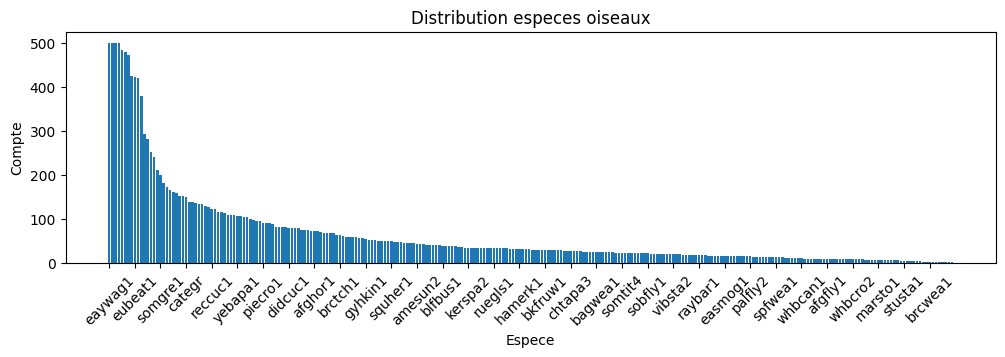

,count,mean,std,min,25%,50%,75%,max
count,264.0,63.310606,96.99807,1.0,14.0,29.5,70.25,500.0


In [15]:
plt.figure(figsize=(12, 3))

count = unique_bird.shape[0]
step = 8

plt.bar([i for i in range(count)], unique_bird.values)

plt.gca().set_xticks([i for i in range(0, count, step)])
plt.gca().set_xticklabels([unique_bird.index[i] for i in range(0, count, step)], rotation=45)

plt.xlabel("Espece")
plt.ylabel("Compte")
plt.title("Distribution especes oiseaux")
plt.show()

print()

display(unique_bird.to_frame().describe().T)

<div class="answer">

* distribution tres mal balancee

In [16]:
import librosa as rosa

from IPython.display import Audio

MIN_RATING = 0
MAX_RATING = 5
viz_data = (raw_df["rating"] <= MAX_RATING) & (raw_df["rating"] >= MIN_RATING)
viz_data = raw_df[ viz_data ]
viz_data.reset_index(inplace=True)

print(viz_data.shape)

(16941, 13)


Num samples: 2787265 Sampling rate: 22050 Duration: 126.4066
Estimer melspectrogram shape: 10099
melspectrogram shape: (128, 10099)


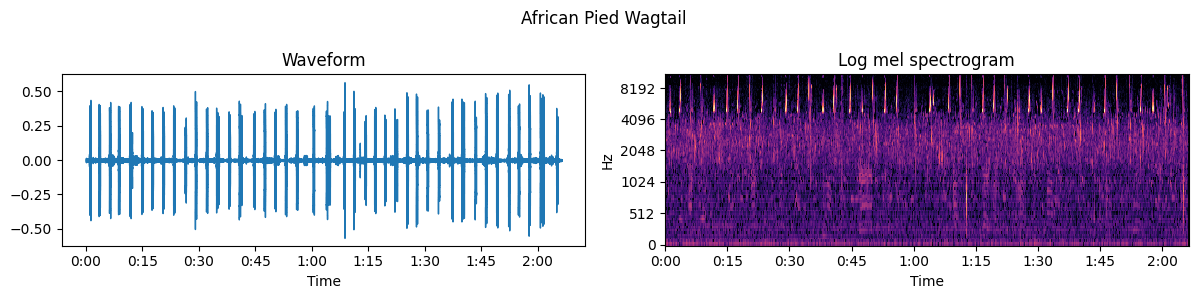

In [17]:
#
# url aide: https://tinyurl.com/3vf92xvx
#
def visualize_audio(id, **kwargs):
    # filename = config.get_audio_filename(valid_data_df.loc[id, "filename"])
    filename = config.get_audio_filename(viz_data.loc[id, "filename"])
    y, sr = rosa.load(filename)
    print("Num samples:", len(y), "Sampling rate:", sr, "Duration:", round(len(y) / sr, 4))

    # besoin de passer certains parametres entre melspectrogram() 
    # et specshow() pour matcher timeline
    display_kwargs = {}

    if "n_fft" in kwargs:
        kwargs["n_fft"] = math.ceil(kwargs["n_fft"] * sr)
        display_kwargs["n_fft"] = kwargs["n_fft"]

    if "hop_length" in kwargs:
        kwargs["hop_length"] = math.ceil(kwargs["hop_length"] * sr)
        display_kwargs["hop_length"] = kwargs["hop_length"]

        # prediction dimension mel spectogram
        window_length = 2048 if not "n_fft" in kwargs else kwargs["n_fft"]

        mel_dim = math.ceil(len(y) / kwargs["hop_length"])
        print("Estimer melspectrogram shape:", mel_dim)

    plt.figure(figsize=(12, 3))
    plt.subplot(121)
    plt.title("Waveform")
    rosa.display.waveshow(y, sr=sr, ax=plt.gca())

    plt.subplot(122)
    plt.title("Log mel spectrogram")
    S = rosa.feature.melspectrogram(y=y,
                                    sr=sr,
                                    **kwargs)
    print("melspectrogram shape:", S.shape)

    S_db = rosa.power_to_db(S, ref=np.max)
    rosa.display.specshow(S_db,
                          x_axis='time',
                          y_axis='mel',
                          sr=sr,
                          ax=plt.gca(),
                          **display_kwargs)
    plt.suptitle(viz_data.loc[id, "common_name"])
    plt.tight_layout()
    plt.show()

    display(Audio(data=y, rate=sr))

STFT_FRAME_SIZE_MS = 12.5 / 1000 # ms
STFT_WINDOW_SIZE_MS = 2 * STFT_FRAME_SIZE_MS # ms

visualize_audio(600,
                n_fft=STFT_WINDOW_SIZE_MS, # ms
                hop_length=STFT_FRAME_SIZE_MS, # ms
                n_mels=128,
                fmin=0,
                fmax=8192)

In [18]:
#
# faudrait faire une analyse sur la duree des samples (on pourrait decider de cropper certains)
# ou meme voir si les fichiers audios pour les classes sous represente sont plus court
#
def assign_audio_spec(filename, audio):
    filename = config.get_audio_filename(filename)
    y, sr = rosa.load(filename)
    audio.append( [sr, len(y), len(y) / sr] )

FORCE_PROCESS_AUDIO_STATS = False

filename = Path.joinpath(config.paths.DATA_RAW_DIR, "audio_stats.csv")

if FORCE_PROCESS_AUDIO_STATS or not Path(filename).is_file():
    selected_audio = valid_data_df[:]

    audio_data = []
    for i in tqdm(range(len(selected_audio))):
        audio_filename = selected_audio.loc[i, "filename"]
        assign_audio_spec(audio_filename, audio_data)

    audio_df = pd.DataFrame(data=audio_data, columns=["SR", "Samples", "Duration"])

    stats_df = pd.concat([selected_audio[["common_name", "filename", "rating"]], audio_df], axis=1)
    stats_df.to_csv(filename, index=False)
else:
    stats_df = pd.read_csv(filename)

In [19]:
groups = group_stats_df = stats_df.iloc[:,-4:].groupby(["rating"])
pp = groups["Duration"].agg([("Q1", lambda x: x.quantile(0.25)),
                                 ("Q2", lambda x: x.quantile(0.50)),
                                 ("Q3", lambda x: x.quantile(0.75)),
                                 ("Min", lambda x: x.min()),
                                 ("Max", lambda x: x.max()),
                                 ("Count", lambda x: len(x))])

display(pp)

,Q1,Q2,Q3,Min,Max,Count
rating,,,,,,
0.0,12.255023,21.174558,41.086429,0.940408,873.299637,512
0.5,11.245612,19.761633,30.099592,3.082449,99.360000,26
1.0,6.974694,12.042063,23.032041,1.253878,145.893016,100
1.5,11.768073,21.655510,40.918798,1.752018,452.022041,167
2.0,8.262007,16.507528,30.739603,0.966576,395.088027,514
2.5,14.347721,26.004943,45.432188,0.864036,2043.167347,940
3.0,9.456247,18.124490,35.088673,0.816009,551.262041,2280
3.5,18.514286,31.359569,55.223152,1.253878,2373.528027,2308
4.0,11.781224,22.099002,40.946939,0.548027,1787.846576,4835
